# Approaches 3-5: Neural Sequence Models, and Comparison of All Five Approaches

*Formative Assignment 2: NLP and Language Technologies*

| Section | Approach | Author |
|---|---|---|
| 2 | 1D CNN | Carla Lisa Batoni |
| 3 | Bidirectional LSTM | Mukunzi Ndahiro James |
| 4 | Fine-tuned AfriBERTa | Mukunzi Ndahiro James |
| 5 | Comparison of all five approaches | Carla Lisa Batoni |
| 6-7 | Error analysis, limitations | Mukunzi Ndahiro James |

Unlike the TF-IDF baselines, these models read the article as an ordered **sequence of tokens**: the CNN detects short local phrases, the BiLSTM carries a memory across the whole sequence, and AfriBERTa relates every token to every other token with self-attention after pretraining on African-language text.



## Setup
Run this cell first. On Google Colab it clones the repository and asks you to upload `Train.csv` (and `Test.csv`) from the Zindi data page; locally it only adds the repository root to the Python path.

In [3]:
import sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("src").exists():
    if not Path("/content/formativeII-NLP").exists():
        !git clone -q https://github.com/mukunzindahiro-max/formativeII-NLP.git /content/formativeII-NLP
    %cd /content/formativeII-NLP

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.data import DATA_DIR

if "google.colab" in sys.modules and not (DATA_DIR / "Train.csv").exists():
    from google.colab import files
    for name, content in files.upload().items():
        (DATA_DIR / name).write_bytes(content)

Saving Test.csv to Test.csv
Saving Train.csv to Train.csv


## 1. Shared setup

- **Data:** the same cleaned data and train/validation split as the baselines. A stratified 10% **development split** is taken from the training part for early stopping and for choosing between experiments, so the validation set is used only for reporting.
- **Tokens:** AfriBERTa's SentencePiece tokeniser (70k subword pieces, trained on Swahili and 10 other African languages) for all three models, truncated to 512 tokens. The CNN is also trained on whole words as a controlled comparison.
- **Class imbalance:** weighted cross-entropy with the square root of balanced class weights (Section 9.5 of notebook 01, following Cui et al., 2019).
- **Training:** AdamW (Loshchilov & Hutter, 2019), gradient clipping at 1.0, early stopping on development macro-F1, fixed seed 42. The weights from the best epoch are kept.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from src.data import FIGURES_DIR, LABELS, RESULTS_DIR, dev_split, load_split, set_seed
from src.evaluate import compute_metrics, evaluate, load_experiments, log_experiment, plot_confusion, plot_history
from src.neural import BiLSTMClassifier, TextCNN, TransformerClassifier, class_weights, get_device, run_experiment
from src.text import WordVocab, load_subword_tokenizer, subword_encode, transformer_encode

set_seed()
device = get_device()
print("Device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

train_df, val_df = load_split()
fit_df, dev_df = dev_split(train_df)
pd.DataFrame({"fit": fit_df["category"].value_counts(), "dev": dev_df["category"].value_counts(),
              "validation": val_df["category"].value_counts()}).loc[LABELS]

Device: cuda Tesla T4


,fit,dev,validation
category,,,
Kitaifa,1440,160,400
michezo,1237,138,344
Biashara,978,109,272
Kimataifa,39,4,11
Burudani,12,1,3


In [5]:
weights = class_weights(fit_df["category"])
pd.Series(weights.numpy(), index=LABELS, name="loss weight").round(2)

,loss weight
Kitaifa,0.25
michezo,0.27
Biashara,0.30
Kimataifa,1.49
Burudani,2.70


In [6]:
MAX_LEN = 512
splits = {"fit": fit_df, "dev": dev_df, "val": val_df}

tokenizer = load_subword_tokenizer()
PAD = tokenizer.pad_token_id
sub = {k: subword_encode(df["content"], tokenizer, MAX_LEN) for k, df in splits.items()}

vocab = WordVocab(fit_df["content"])
word = {k: vocab.encode(df["content"], MAX_LEN) for k, df in splits.items()}

print(f"Subword vocabulary: {len(tokenizer):,} pieces")
print(f"Word vocabulary (min count 2): {len(vocab):,} words; validation out-of-vocabulary rate {vocab.oov_rate(val_df['content']):.1%}")
print(f"Median input length: {np.median([len(s) for s in sub['fit']]):.0f} subwords vs "
      f"{np.median([len(s) for s in word['fit']]):.0f} words (after truncation to {MAX_LEN})")

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/257 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 1.55MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Subword vocabulary: 70,005 pieces
Word vocabulary (min count 2): 28,412 words; validation out-of-vocabulary rate 4.8%
Median input length: 377 subwords vs 279 words (after truncation to 512)


In [7]:
runs = {}

def record(model_name, experiment, change, run):
    run["model"].cpu()
    runs[experiment] = run
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    metrics, _ = compute_metrics(val_df["category"].to_numpy(), run["val_proba"])
    plot_history(run["history"], f"{experiment} ({run['n_params'] / 1e6:.1f}M parameters)",
                 save_as=f"curve_{experiment}.png")
    return log_experiment(model_name, experiment, change, run["dev_macro_f1"], metrics, run["train_time_s"])

def finalise(model_name, experiments, title):
    best = max(experiments, key=lambda e: runs[e]["dev_macro_f1"])
    print(f"Selected by development macro-F1: {best}")
    display(load_experiments(model_name))
    metrics, pred = evaluate(model_name, val_df, runs[best]["val_proba"])
    plot_confusion(val_df["category"], pred, f"{title} (validation)", save_as=f"cm_{model_name}.png")
    plt.show()
    return best, metrics, pred

## 2. Approach 3: 1D CNN

**Author:** Carla Lisa Batoni

Architecture (Kim, 2014): 128-dimensional token embeddings learned from scratch → three parallel 1D convolutions with window sizes 3, 4, and 5 (128 filters each) → ReLU → max-pooling over the full sequence (padding masked out) → dropout (0.5) → linear layer. Max-pooling retains each filter's strongest match anywhere in the article, so the model detects *which* short phrases occur, but not *where* they occur or their order beyond the 5-token window.

Training: AdamW, learning rate 1e-3, batch size 32, at most 15 epochs, early stopping after 3 epochs without improvement.

**Experiment 1, `cnn_subword`:** subword tokens, no class weights. This shows how the architecture handles the imbalance on its own.

/content/formativeII-NLP/src/neural.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


epoch 1: train loss 1.101, dev loss 0.670, dev macro-F1 0.454
epoch 2: train loss 0.682, dev loss 0.520, dev macro-F1 0.487
epoch 3: train loss 0.552, dev loss 0.647, dev macro-F1 0.416
epoch 4: train loss 0.487, dev loss 0.467, dev macro-F1 0.511
epoch 5: train loss 0.427, dev loss 0.471, dev macro-F1 0.486
epoch 6: train loss 0.384, dev loss 0.546, dev macro-F1 0.466
epoch 7: train loss 0.337, dev loss 0.422, dev macro-F1 0.518
epoch 8: train loss 0.312, dev loss 0.468, dev macro-F1 0.510
epoch 9: train loss 0.297, dev loss 0.474, dev macro-F1 0.504
epoch 10: train loss 0.269, dev loss 0.461, dev macro-F1 0.511
early stopping after epoch 10


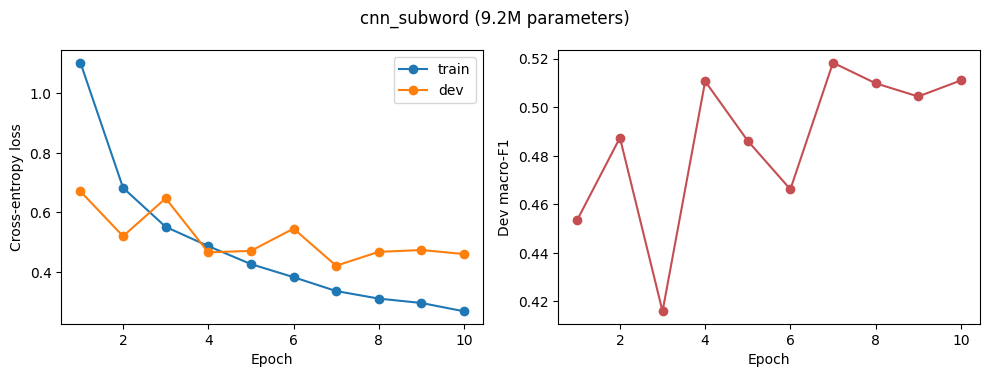

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,cnn,cnn_subword,"subword tokens, no class weights",0.5183,0.5243,0.8738,0.8689,0.404,17.3


In [8]:
cnn_run = run_experiment(lambda: TextCNN(len(tokenizer), PAD), sub["fit"], sub["dev"], sub["val"],
                         fit_df, dev_df, val_df, PAD, epochs=15, lr=1e-3)
record("cnn", "cnn_subword", "subword tokens, no class weights", cnn_run)

**Experiment 2, `cnn_subword_weighted`:** the same model with the weighted loss. Without weights, the 13 `Burudani` training articles contribute almost nothing to the gradient, so we expect weighting to raise recall on the two small classes, possibly at a small cost in precision.

/content/formativeII-NLP/src/neural.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


epoch 1: train loss 1.340, dev loss 0.699, dev macro-F1 0.452
epoch 2: train loss 0.851, dev loss 0.551, dev macro-F1 0.479
epoch 3: train loss 0.632, dev loss 0.546, dev macro-F1 0.467
epoch 4: train loss 0.558, dev loss 0.496, dev macro-F1 0.496
epoch 5: train loss 0.483, dev loss 0.464, dev macro-F1 0.500
epoch 6: train loss 0.416, dev loss 0.454, dev macro-F1 0.495
epoch 7: train loss 0.377, dev loss 0.428, dev macro-F1 0.524
epoch 8: train loss 0.344, dev loss 0.421, dev macro-F1 0.506
epoch 9: train loss 0.338, dev loss 0.455, dev macro-F1 0.505
epoch 10: train loss 0.309, dev loss 0.457, dev macro-F1 0.498
early stopping after epoch 10


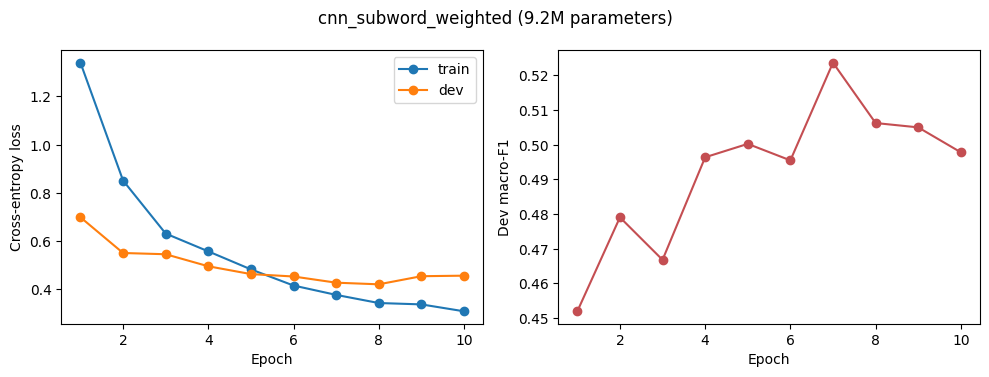

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,cnn,cnn_subword_weighted,"subword tokens, sqrt-balanced class weights",0.5237,0.5206,0.8677,0.8621,0.406,15.5


In [9]:
cnn_run = run_experiment(lambda: TextCNN(len(tokenizer), PAD), sub["fit"], sub["dev"], sub["val"],
                         fit_df, dev_df, val_df, PAD, epochs=15, lr=1e-3, weights=weights)
record("cnn", "cnn_subword_weighted", "subword tokens, sqrt-balanced class weights", cnn_run)

**Experiment 3, `cnn_word_weighted`:** whole-word tokens with the weighted loss. This isolates the effect of the tokeniser: the EDA found that 53.5% of word forms occur only once, so a word-level CNN has to learn a separate embedding for each inflected form, and unseen forms become `<unk>`.

/content/formativeII-NLP/src/neural.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


epoch 1: train loss 1.261, dev loss 0.712, dev macro-F1 0.455
epoch 2: train loss 0.759, dev loss 0.540, dev macro-F1 0.474
epoch 3: train loss 0.596, dev loss 0.643, dev macro-F1 0.403
epoch 4: train loss 0.494, dev loss 0.469, dev macro-F1 0.492
epoch 5: train loss 0.433, dev loss 0.464, dev macro-F1 0.490
epoch 6: train loss 0.385, dev loss 0.563, dev macro-F1 0.470
epoch 7: train loss 0.321, dev loss 0.433, dev macro-F1 0.501
epoch 8: train loss 0.302, dev loss 0.442, dev macro-F1 0.494
epoch 9: train loss 0.271, dev loss 0.465, dev macro-F1 0.499
epoch 10: train loss 0.243, dev loss 0.440, dev macro-F1 0.501
early stopping after epoch 10


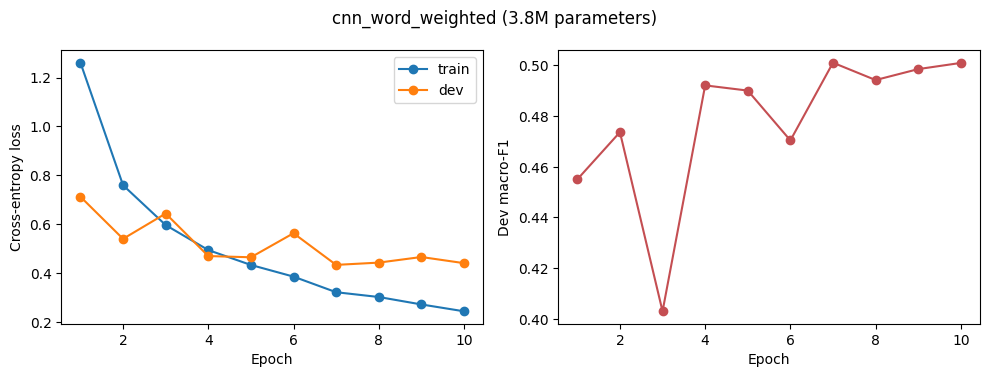

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,cnn,cnn_word_weighted,"word tokens (min count 2), sqrt-balanced class...",0.5011,0.6029,0.862,0.8602,0.3986,13.4


In [10]:
cnn_run = run_experiment(lambda: TextCNN(len(vocab), vocab.pad_id), word["fit"], word["dev"], word["val"],
                         fit_df, dev_df, val_df, vocab.pad_id, epochs=15, lr=1e-3, weights=weights)
record("cnn", "cnn_word_weighted", "word tokens (min count 2), sqrt-balanced class weights", cnn_run)

Selected by development macro-F1: cnn_subword_weighted


,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,cnn,cnn_subword,"subword tokens, no class weights",0.5183,0.5243,0.8738,0.8689,0.4040,17.3
1,cnn,cnn_subword_weighted,"subword tokens, sqrt-balanced class weights",0.5237,0.5206,0.8677,0.8621,0.4060,15.5
2,cnn,cnn_word_weighted,"word tokens (min count 2), sqrt-balanced class...",0.5011,0.6029,0.8620,0.8602,0.3986,13.4


cnn: macro-F1 0.521 (95% CI 0.508-0.533), accuracy 0.862, log loss 0.406
              precision    recall  f1-score   support

     Kitaifa      0.861     0.802     0.831       400
     michezo      0.947     0.942     0.945       344
    Biashara      0.771     0.893     0.828       272
   Kimataifa      0.000     0.000     0.000        11
    Burudani      0.000     0.000     0.000         3

    accuracy                          0.862      1030
   macro avg      0.516     0.528     0.521      1030
weighted avg      0.854     0.862     0.857      1030



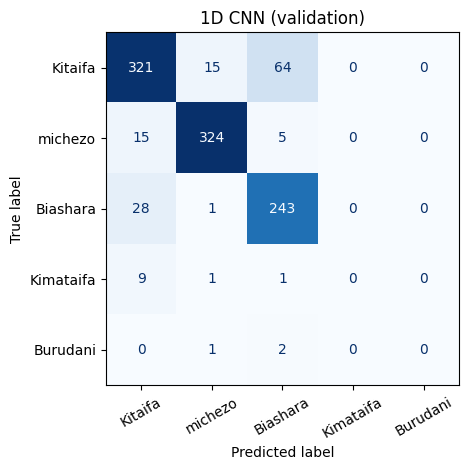

In [11]:
best_cnn, cnn_metrics, cnn_pred = finalise("cnn", ["cnn_subword", "cnn_subword_weighted", "cnn_word_weighted"], "1D CNN")

**Findings.**
- **Selected model:** `cnn_subword_weighted` (development macro-F1 0.524). On validation it reaches macro-F1 0.521 (95% CI 0.508-0.533) and accuracy 0.862.
- **The CNN never recognises the two small classes.** `Kimataifa` and `Burudani` both have F1 = 0, so macro-F1 is simply the three large-class F1 scores divided by five. This is also why its confidence interval is so narrow: resampling cannot change a class that is always wrong. On the three large classes (macro-F1 0.868) the CNN is close to TF-IDF + LR (0.879). Max-pooling over 3-5-token filters acts as a learned keyword and phrase detector, so the CNN rediscovers roughly what TF-IDF already captures.
- **Class weights did not help.** Weighting left small-class recall at zero and slightly lowered accuracy (0.862 vs 0.869). With 39 `Kimataifa` and 12 `Burudani` training articles and embeddings learned from scratch, weighting scales the gradient of a few examples but does not add the evidence the filters need.
- **Word vs subword tokens: no reliable difference.** The word-level CNN had the *lowest* development score (0.501) but the *highest* validation macro-F1 (0.603). Its three-class score is lower (0.862), so the gap comes from a few small-class articles, which is within noise. The word vocabulary's validation out-of-vocabulary rate is only 4.8%: the 53.5% hapax rate from notebook 01 describes the vocabulary, but those rare forms cover few running tokens, so morphology hurts a word-level model less than expected.
- **Learning curves:** training loss keeps falling (1.10 → 0.27) while development loss levels off around 0.42-0.47 from epoch 7. Development macro-F1 jumps by ±0.05 between epochs because the development split holds only 1 `Burudani` and 4 `Kimataifa` articles.

## 3. Approach 4: Bidirectional LSTM (BILSTM)

**Author:** Mukunzi Ndahiro James

Architecture (Hochreiter & Schmidhuber, 1997; Schuster & Paliwal, 1997): 128-dimensional subword embeddings → one bidirectional LSTM layer with 128 units per direction (padded positions are skipped with packed sequences) → pooling → dropout 0.3 → linear layer. Unlike the CNN, the LSTM reads tokens in order and updates a memory at every step, so in principle it can use context spread across several sentences.

Training: AdamW, learning rate 1e-3, batch size 32, at most 12 epochs, early stopping after 3 epochs without improvement, weighted loss (the small classes need it; see the CNN experiments).

**Experiment 1, `bilstm_last`:** the article is represented by the final hidden state of each direction, which must summarise up to 512 tokens.

/content/formativeII-NLP/src/neural.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


epoch 1: train loss 1.138, dev loss 0.775, dev macro-F1 0.494
epoch 2: train loss 0.670, dev loss 0.644, dev macro-F1 0.592
epoch 3: train loss 0.486, dev loss 0.539, dev macro-F1 0.684
epoch 4: train loss 0.335, dev loss 0.616, dev macro-F1 0.731
epoch 5: train loss 0.241, dev loss 0.638, dev macro-F1 0.737
epoch 6: train loss 0.126, dev loss 0.618, dev macro-F1 0.742
epoch 7: train loss 0.064, dev loss 0.813, dev macro-F1 0.482
epoch 8: train loss 0.034, dev loss 0.743, dev macro-F1 0.541
epoch 9: train loss 0.026, dev loss 0.845, dev macro-F1 0.480
early stopping after epoch 9


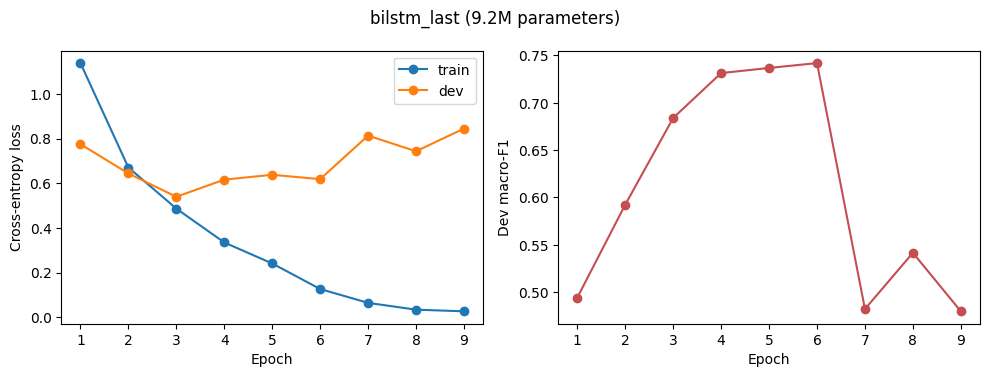

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,bilstm,bilstm_last,"final hidden states, 512 tokens",0.7419,0.5795,0.8314,0.8262,0.5572,48.7


In [12]:
lstm_run = run_experiment(lambda: BiLSTMClassifier(len(tokenizer), PAD, pooling="last"), sub["fit"], sub["dev"], sub["val"],
                          fit_df, dev_df, val_df, PAD, epochs=12, lr=1e-3, weights=weights)
record("bilstm", "bilstm_last", "final hidden states, 512 tokens", lstm_run)

**Experiment 2, `bilstm_attention`:** attention pooling (Yang et al., 2016). A learned score for every position decides how much each hidden state contributes, so evidence near the start of a long article does not have to survive hundreds of LSTM steps. If this beats experiment 1, it suggests the LSTM memory fades over long articles.

/content/formativeII-NLP/src/neural.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


epoch 1: train loss 1.117, dev loss 0.776, dev macro-F1 0.309
epoch 2: train loss 0.771, dev loss 0.773, dev macro-F1 0.418
epoch 3: train loss 0.603, dev loss 0.598, dev macro-F1 0.464
epoch 4: train loss 0.477, dev loss 0.601, dev macro-F1 0.457
epoch 5: train loss 0.375, dev loss 0.762, dev macro-F1 0.483
epoch 6: train loss 0.275, dev loss 0.675, dev macro-F1 0.478
epoch 7: train loss 0.224, dev loss 0.687, dev macro-F1 0.483
epoch 8: train loss 0.150, dev loss 0.647, dev macro-F1 0.489
epoch 9: train loss 0.109, dev loss 0.872, dev macro-F1 0.519
epoch 10: train loss 0.079, dev loss 0.793, dev macro-F1 0.483
epoch 11: train loss 0.059, dev loss 0.963, dev macro-F1 0.478
epoch 12: train loss 0.040, dev loss 1.118, dev macro-F1 0.475
early stopping after epoch 12


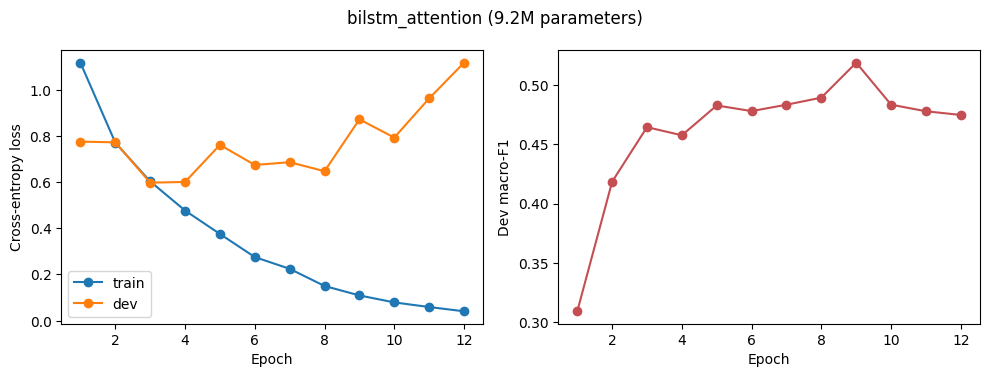

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,bilstm,bilstm_attention,"attention pooling, 512 tokens",0.5185,0.5505,0.8391,0.832,0.6274,69.4


In [13]:
lstm_run = run_experiment(lambda: BiLSTMClassifier(len(tokenizer), PAD, pooling="attention"), sub["fit"], sub["dev"], sub["val"],
                          fit_df, dev_df, val_df, PAD, epochs=12, lr=1e-3, weights=weights)
record("bilstm", "bilstm_attention", "attention pooling, 512 tokens", lstm_run)

**Experiment 3, `bilstm_best_256`:** the better pooling from experiments 1-2 (chosen on development macro-F1), but reading only the first 256 tokens. If the score barely drops, the topic is decided early in the article and longer inputs mainly add cost.

/content/formativeII-NLP/src/neural.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


epoch 1: train loss 1.143, dev loss 0.772, dev macro-F1 0.571
epoch 2: train loss 0.682, dev loss 0.599, dev macro-F1 0.642
epoch 3: train loss 0.493, dev loss 0.606, dev macro-F1 0.535
epoch 4: train loss 0.334, dev loss 0.570, dev macro-F1 0.675
epoch 5: train loss 0.224, dev loss 0.641, dev macro-F1 0.722
epoch 6: train loss 0.145, dev loss 0.608, dev macro-F1 0.766
epoch 7: train loss 0.075, dev loss 0.695, dev macro-F1 0.721
epoch 8: train loss 0.039, dev loss 0.778, dev macro-F1 0.678
epoch 9: train loss 0.020, dev loss 0.966, dev macro-F1 0.685
early stopping after epoch 9


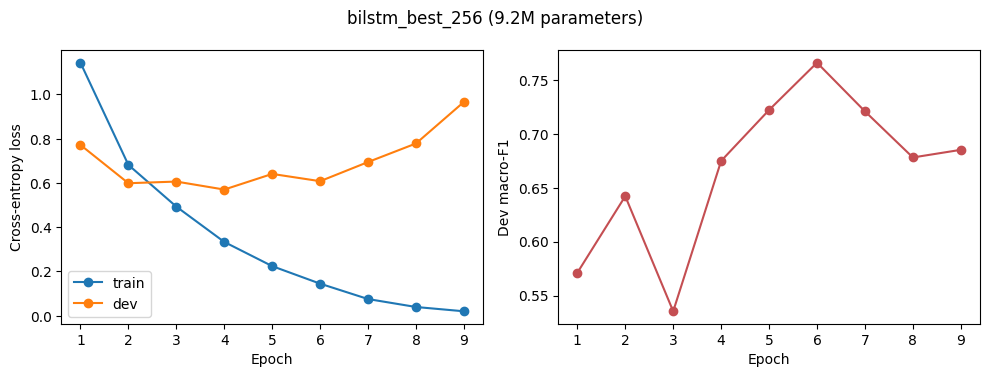

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,bilstm,bilstm_best_256,"last pooling, first 256 tokens",0.7658,0.5778,0.8345,0.8282,0.5493,28.6


In [14]:
best_pooling = "attention" if runs["bilstm_attention"]["dev_macro_f1"] >= runs["bilstm_last"]["dev_macro_f1"] else "last"
short = {k: [s[:256] for s in seqs] for k, seqs in sub.items()}
lstm_run = run_experiment(lambda: BiLSTMClassifier(len(tokenizer), PAD, pooling=best_pooling), short["fit"], short["dev"], short["val"],
                          fit_df, dev_df, val_df, PAD, epochs=12, lr=1e-3, weights=weights)
record("bilstm", "bilstm_best_256", f"{best_pooling} pooling, first 256 tokens", lstm_run)

Selected by development macro-F1: bilstm_best_256


,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,bilstm,bilstm_last,"final hidden states, 512 tokens",0.7419,0.5795,0.8314,0.8262,0.5572,48.7
1,bilstm,bilstm_attention,"attention pooling, 512 tokens",0.5185,0.5505,0.8391,0.8320,0.6274,69.4
2,bilstm,bilstm_best_256,"last pooling, first 256 tokens",0.7658,0.5778,0.8345,0.8282,0.5493,28.6


bilstm: macro-F1 0.578 (95% CI 0.494-0.666), accuracy 0.828, log loss 0.549
              precision    recall  f1-score   support

     Kitaifa      0.804     0.820     0.812       400
     michezo      0.878     0.922     0.899       344
    Biashara      0.831     0.757     0.792       272
   Kimataifa      0.111     0.091     0.100        11
    Burudani      0.250     0.333     0.286         3

    accuracy                          0.828      1030
   macro avg      0.575     0.585     0.578      1030
weighted avg      0.827     0.828     0.827      1030



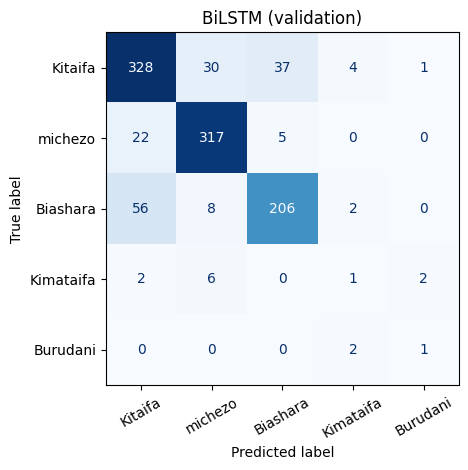

In [15]:
best_lstm, lstm_metrics, lstm_pred = finalise("bilstm", ["bilstm_last", "bilstm_attention", "bilstm_best_256"], "BiLSTM")

**Findings.**
- **Selected model:** `bilstm_best_256` (development macro-F1 0.766). On validation it reaches macro-F1 0.578 (95% CI 0.494-0.666) and accuracy 0.828, the lowest accuracy and three-class macro-F1 (0.834) of all five approaches.
- **Strong overfitting.** In every run training loss falls to 0.02-0.04 while development loss rises after epoch 3 (0.54 → 0.85 for `bilstm_last`). The model has 9.2M parameters, mostly a 70k × 128 embedding table learned from scratch on 3,706 articles, far more capacity than the data can constrain.
- **Attention pooling did not help** (development 0.519 vs 0.742; validation 0.551 vs 0.580). The hypothesis that the LSTM's memory fades over long articles is not supported; the bottleneck appears to be data size and overfitting, and attention adds more parameters to overfit.
- **256 tokens are as good as 512** (validation macro-F1 0.578 vs 0.580, three-class 0.835 vs 0.831) and train 1.7× faster. The topic of a news article is set in its opening paragraph, which also explains why truncation costs little in Section 5.
- **Model selection on the development split is unreliable.** `bilstm_last` dropped from 0.742 to 0.482 development macro-F1 between epochs 6 and 7. Losing the single development `Burudani` article moves macro-F1 by 0.2, so the experiment chosen on development data (`bilstm_best_256`) is not better on validation.
- **Compared with the CNN**, the BiLSTM is the only from-scratch model that finds a `Burudani` article (F1 0.286), but it is worse on the large classes, and McNemar's test shows the CNN makes significantly fewer errors (110 vs 75 articles only one of them gets right, p = 0.012). On this data, reading the sequence token by token helped less than detecting local phrases.

## 4. Approach 5: Fine-tuned AfriBERTa

**Author:** Mukunzi Ndahiro James

AfriBERTa-base (Ogueji et al., 2021) is an 8-layer transformer encoder (111M parameters) pretrained with masked language modelling on less than 1 GB of text in 11 African languages, including Swahili. A linear classification layer is added on top of the `<s>` token representation and the whole network is fine-tuned (Wolf et al., 2020).

Training: AdamW, learning rate 3e-5, weight decay 0.01, linear warm-up over the first 10% of steps then linear decay, batch size 16, at most 5 epochs, early stopping after 2 epochs without improvement, mixed precision on GPU.

In [16]:
head = {k: transformer_encode(df["content"], tokenizer, MAX_LEN, "head") for k, df in splits.items()}
head_tail = {k: transformer_encode(df["content"], tokenizer, MAX_LEN, "head_tail", head_len=128) for k, df in splits.items()}
full_len = pd.Series([len(s) for s in subword_encode(val_df["content"], tokenizer, 100000)])
print(f"Validation articles longer than 510 subword tokens (truncated): {(full_len > 510).mean():.1%}")

AFRI = dict(epochs=5, lr=3e-5, batch_size=16, patience=2, weight_decay=0.01, warmup=0.1)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (582 > 512). Running this sequence through the model will result in indexing errors


Validation articles longer than 510 subword tokens (truncated): 27.1%


**Experiment 1, `afriberta_head`:** first 510 tokens, unweighted loss. Pretraining may already give the small classes useful representations, so we first test without weighting.

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  446MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/formativeII-NLP/src/neural.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is 

model.safetensors: reconstructing file:   0%|          |  0.00B /  446MB            

model.safetensors: downloading bytes:           |  0.00B            

epoch 1: train loss 0.599, dev loss 0.351, dev macro-F1 0.519
epoch 2: train loss 0.272, dev loss 0.395, dev macro-F1 0.729
epoch 3: train loss 0.170, dev loss 0.477, dev macro-F1 0.789
epoch 4: train loss 0.102, dev loss 0.526, dev macro-F1 0.814
epoch 5: train loss 0.069, dev loss 0.554, dev macro-F1 0.844


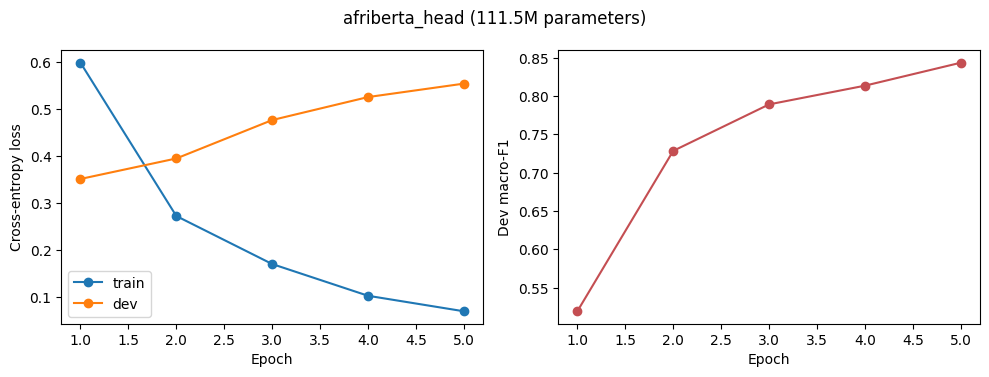

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,afriberta,afriberta_head,"first 510 tokens, no class weights",0.8437,0.7822,0.9248,0.9214,0.3921,333.3


In [17]:
afri_run = run_experiment(TransformerClassifier, head["fit"], head["dev"], head["val"],
                          fit_df, dev_df, val_df, PAD, **AFRI)
record("afriberta", "afriberta_head", "first 510 tokens, no class weights", afri_run)

**Experiment 2, `afriberta_head_weighted`:** the same with the weighted loss.

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/formativeII-NLP/src/neural.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is 

epoch 1: train loss 0.692, dev loss 0.372, dev macro-F1 0.611
epoch 2: train loss 0.324, dev loss 0.418, dev macro-F1 0.817
epoch 3: train loss 0.190, dev loss 0.429, dev macro-F1 0.788
epoch 4: train loss 0.117, dev loss 0.575, dev macro-F1 0.836
epoch 5: train loss 0.072, dev loss 0.583, dev macro-F1 0.829


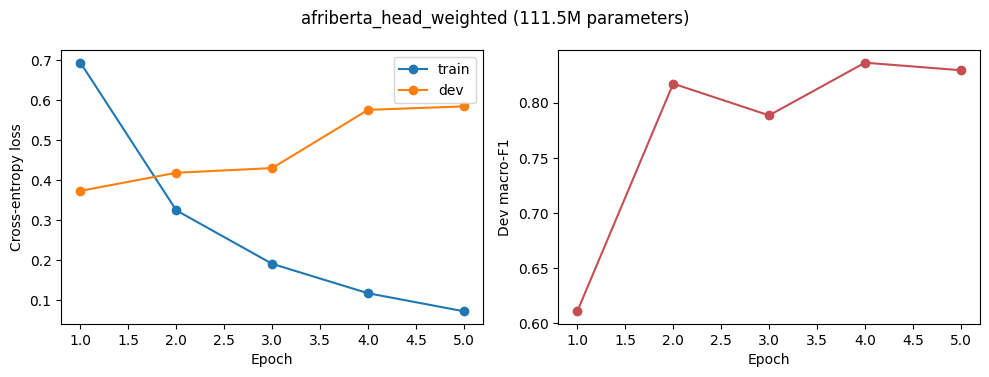

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,afriberta,afriberta_head_weighted,"first 510 tokens, sqrt-balanced class weights",0.8361,0.7696,0.9186,0.9155,0.3899,334.3


In [18]:
afri_run = run_experiment(TransformerClassifier, head["fit"], head["dev"], head["val"],
                          fit_df, dev_df, val_df, PAD, weights=weights, **AFRI)
record("afriberta", "afriberta_head_weighted", "first 510 tokens, sqrt-balanced class weights", afri_run)

**Experiment 3, `afriberta_head_tail`:** the better weighting from experiments 1-2, with head+tail truncation: the first 128 and the last 382 tokens (Sun et al., 2019). Only articles longer than 510 tokens are affected. If it helps, the end of long articles carries information that plain truncation throws away.

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/content/formativeII-NLP/src/neural.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is 

epoch 1: train loss 0.595, dev loss 0.334, dev macro-F1 0.528
epoch 2: train loss 0.273, dev loss 0.293, dev macro-F1 0.650
epoch 3: train loss 0.161, dev loss 0.456, dev macro-F1 0.818
epoch 4: train loss 0.101, dev loss 0.486, dev macro-F1 0.829
epoch 5: train loss 0.070, dev loss 0.500, dev macro-F1 0.796


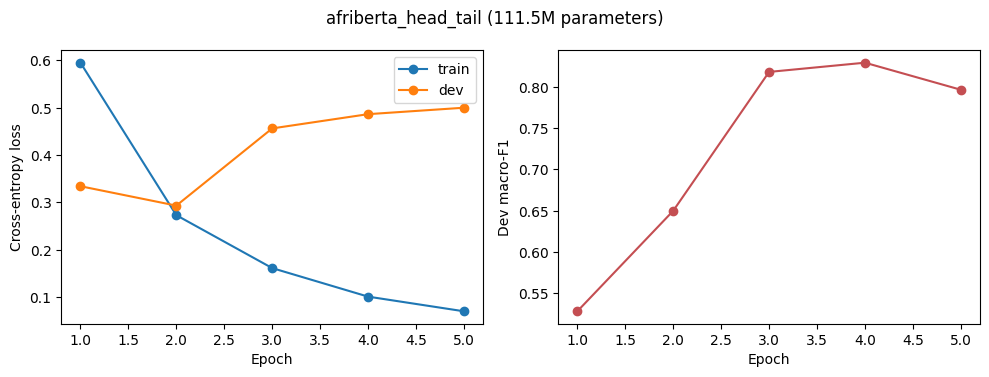

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,afriberta,afriberta_head_tail,"first 128 + last 382 tokens, no class weights",0.8291,0.7469,0.9297,0.9243,0.3522,334.5


In [19]:
use_weights = runs["afriberta_head_weighted"]["dev_macro_f1"] >= runs["afriberta_head"]["dev_macro_f1"]
afri_run = run_experiment(TransformerClassifier, head_tail["fit"], head_tail["dev"], head_tail["val"],
                          fit_df, dev_df, val_df, PAD, weights=weights if use_weights else None, **AFRI)
record("afriberta", "afriberta_head_tail",
       f"first 128 + last 382 tokens, {'sqrt-balanced class weights' if use_weights else 'no class weights'}", afri_run)

Selected by development macro-F1: afriberta_head


,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,afriberta,afriberta_head,"first 510 tokens, no class weights",0.8437,0.7822,0.9248,0.9214,0.3921,333.3
1,afriberta,afriberta_head_weighted,"first 510 tokens, sqrt-balanced class weights",0.8361,0.7696,0.9186,0.9155,0.3899,334.3
2,afriberta,afriberta_head_tail,"first 128 + last 382 tokens, no class weights",0.8291,0.7469,0.9297,0.9243,0.3522,334.5


afriberta: macro-F1 0.782 (95% CI 0.641-0.889), accuracy 0.921, log loss 0.392
              precision    recall  f1-score   support

     Kitaifa      0.928     0.873     0.899       400
     michezo      0.963     0.983     0.973       344
    Biashara      0.873     0.934     0.902       272
   Kimataifa      0.636     0.636     0.636        11
    Burudani      1.000     0.333     0.500         3

    accuracy                          0.921      1030
   macro avg      0.880     0.752     0.782      1030
weighted avg      0.922     0.921     0.921      1030



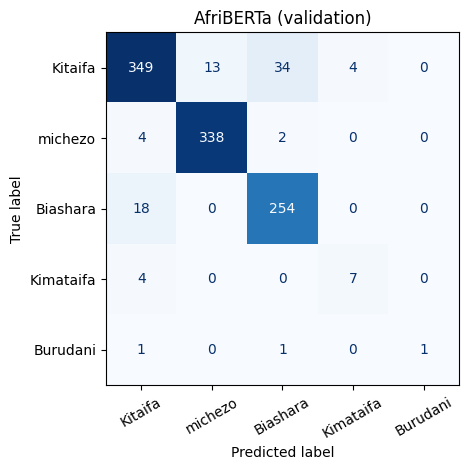

In [20]:
best_afri, afri_metrics, afri_pred = finalise("afriberta", ["afriberta_head", "afriberta_head_weighted", "afriberta_head_tail"], "AfriBERTa")

**Findings.**
- **Selected model:** `afriberta_head` (first 510 tokens, no class weights; development macro-F1 0.844). On validation it reaches **macro-F1 0.782 (95% CI 0.641-0.889), accuracy 0.921, three-class macro-F1 0.925 and log loss 0.392**, the best score on every metric and every class.
- **Pretraining is what helps the small classes.** AfriBERTa is the only model with useful F1 on both: `Kimataifa` 0.636 (7 of 11 found) and `Burudani` 0.500 (1 of 3 found, no false positives). It brings knowledge of Swahili words and names that the CNN and BiLSTM cannot learn from 12-39 training articles.
- **Class weights did not help** (validation 0.770 vs 0.782, development 0.836 vs 0.844). The pretrained representations already separate the small classes, so weighting brings no benefit.
- **Head+tail truncation gave the best large-class results** (accuracy 0.924, three-class macro-F1 0.930, log loss 0.352) but a lower macro-F1 (0.747). Truncation only affects long articles, and no `Burudani` and only 3.7% of `Kimataifa` articles are longer than 510 tokens, so the macro-F1 drop reflects run-to-run variation on 14 small-class articles, not the truncation strategy. On the three large classes, where truncation does happen, the end of the text adds only a little (+0.005 three-class macro-F1).
- **Learning curves:** development loss rises from epoch 1 (0.35 → 0.55) while development macro-F1 keeps improving up to epoch 5 (0.52 → 0.84). The model becomes more confident, which is penalised on its remaining errors, while its decisions on the small classes keep improving. Training stopped at the 5-epoch limit with development macro-F1 still rising, so a longer schedule is worth testing.
- **Cost:** about 5.5 minutes per run on a T4 GPU with 111M parameters, compared with 15-70 seconds for the CNN and BiLSTM on the same GPU.

## 5. Comparison of all five approaches

**Author:** Carla Lisa Batoni

This section only loads saved results from `results/`, so it can be re-run without retraining.

In [21]:
from scipy.stats import binomtest

from src.evaluate import load_final_results
from src.text import truncate_to_subwords

FINAL = ["tfidf_logreg", "tfidf_nb", "cnn", "bilstm", "afriberta"]
NAMES = {"tfidf_logreg": "TF-IDF + LR", "tfidf_nb": "TF-IDF + NB", "cnn": "CNN", "bilstm": "BiLSTM", "afriberta": "AfriBERTa"}
metrics, preds = load_final_results(FINAL)
preds = {m: p.set_index("id").loc[val_df["id"]].reset_index() for m, p in preds.items()}

table = metrics.rename(index=NAMES)
table.insert(1, "macro_f1_95ci", table.apply(lambda r: f"{r.macro_f1_ci_low:.3f}-{r.macro_f1_ci_high:.3f}", axis=1))
table = table.drop(columns=["macro_f1_ci_low", "macro_f1_ci_high"])
table.to_csv(RESULTS_DIR / "model_comparison.csv")
table.round(3)

,macro_f1,macro_f1_95ci,macro_f1_major,accuracy,log_loss,f1_Kitaifa,f1_michezo,f1_Biashara,f1_Kimataifa,f1_Burudani
model,,,,,,,,,,
TF-IDF + LR,0.633,0.561-0.684,0.879,0.874,0.457,0.847,0.947,0.843,0.526,0.000
TF-IDF + NB,0.621,0.538-0.680,0.858,0.852,0.526,0.822,0.929,0.821,0.533,0.000
CNN,0.521,0.508-0.533,0.868,0.862,0.406,0.831,0.945,0.828,0.000,0.000
BiLSTM,0.578,0.494-0.666,0.834,0.828,0.549,0.812,0.899,0.792,0.100,0.286
AfriBERTa,0.782,0.641-0.889,0.925,0.921,0.392,0.899,0.973,0.902,0.636,0.500


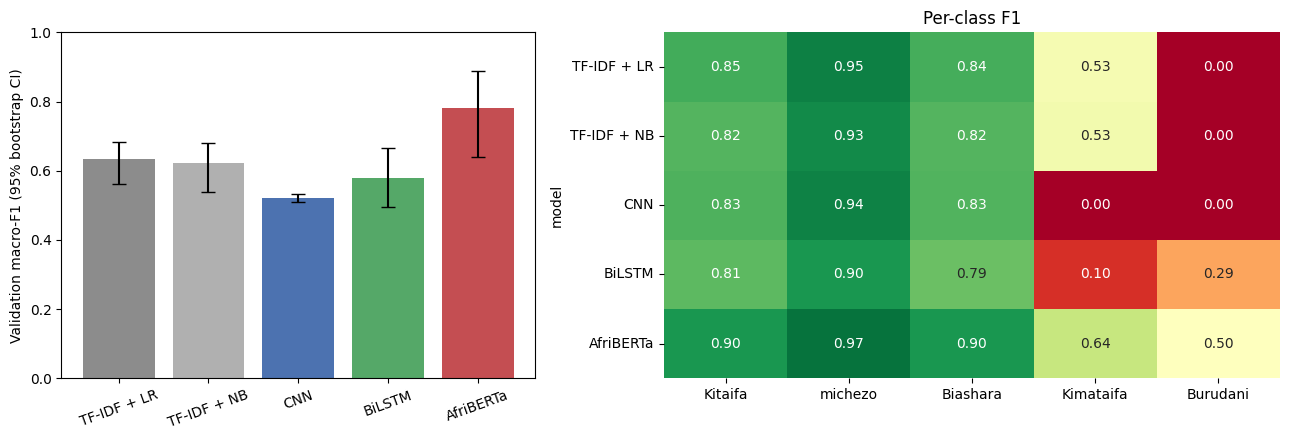

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 1.3]})
m = metrics.rename(index=NAMES)
axes[0].bar(m.index, m["macro_f1"], yerr=[m["macro_f1"] - m["macro_f1_ci_low"], m["macro_f1_ci_high"] - m["macro_f1"]],
            capsize=5, color=["#8C8C8C", "#B0B0B0", "#4C72B0", "#55A868", "#C44E52"])
axes[0].set_ylabel("Validation macro-F1 (95% bootstrap CI)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
sns.heatmap(m[[f"f1_{l}" for l in LABELS]].set_axis(LABELS, axis=1), annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title("Per-class F1")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_macro_f1_per_class.png", dpi=150)
plt.show()

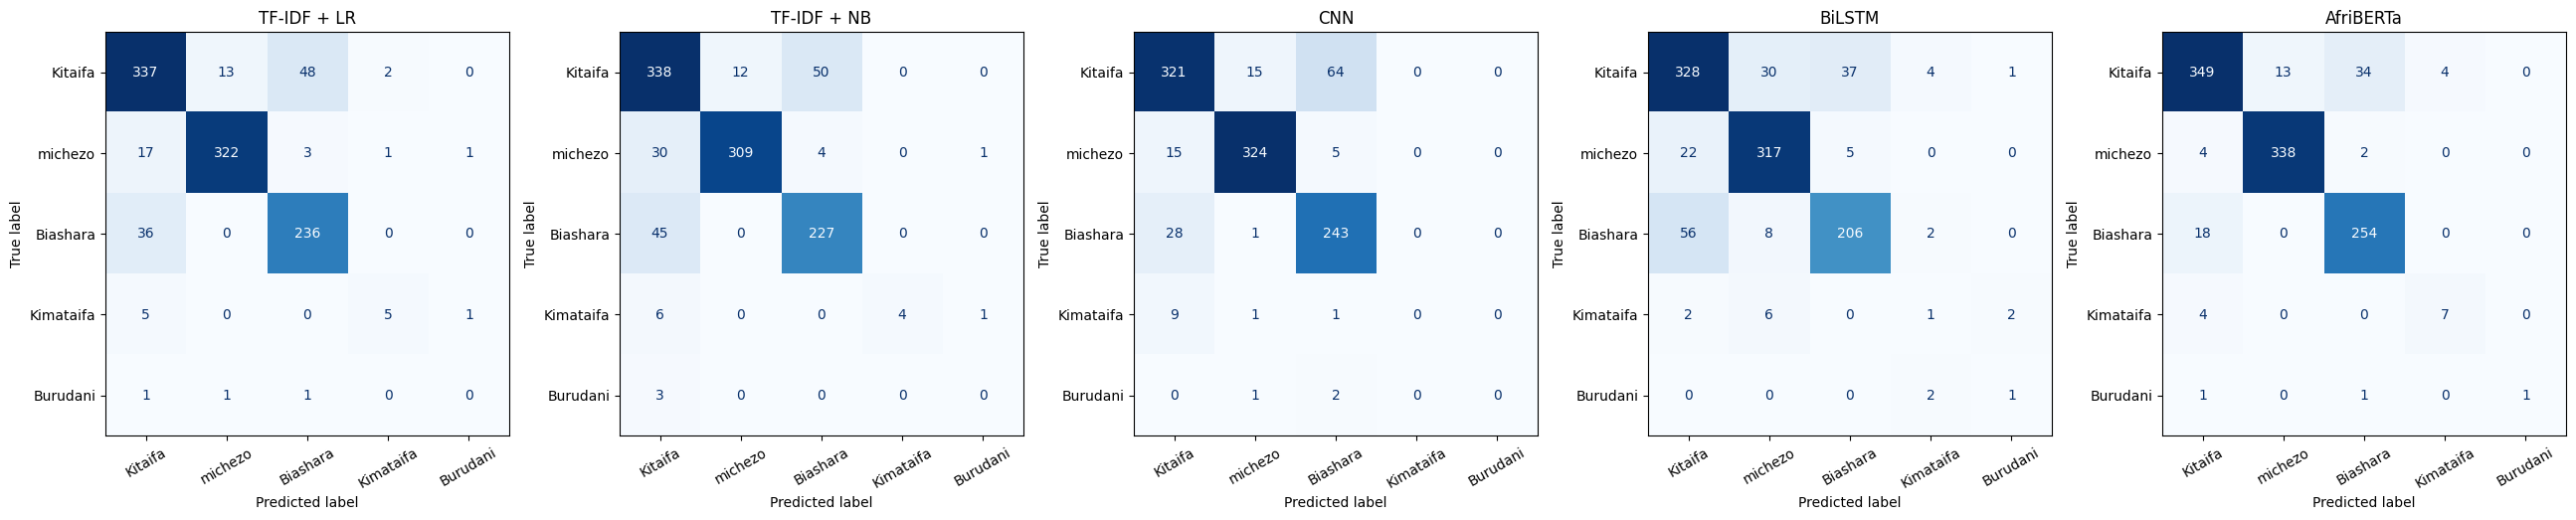

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for ax, name in zip(axes, FINAL):
    plot_confusion(preds[name]["category"], preds[name]["predicted"], NAMES[name], ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_confusion_matrices.png", dpi=150)
plt.show()

### 5.1 All experiments
The full experiment log across both notebooks. `selection_macro_f1` is the cross-validation score (baselines) or development score (neural models) used to pick each model's final configuration.

In [24]:
load_experiments()

,model,experiment,change,selection_macro_f1,val_macro_f1,val_macro_f1_major,val_accuracy,val_log_loss,train_time_s
0,tfidf_logreg,lr_unigram,"unigrams, balanced class weights, best C=1",0.6503,0.6326,0.8789,0.8738,0.4575,22.0
1,tfidf_logreg,lr_bigram,"unigrams + bigrams, balanced class weights, be...",0.6145,0.6278,0.8596,0.8534,1.0048,58.1
2,tfidf_logreg,lr_unigram_unweighted,"unigrams, no class weights, best C=100",0.5515,0.5892,0.8794,0.8767,0.3801,20.8
3,tfidf_nb,nb_multinomial,"multinomial NB, learned class prior, best alph...",0.5410,0.5430,0.8494,0.8447,0.5654,13.3
4,tfidf_nb,nb_multinomial_uniform_prior,"multinomial NB, uniform class prior, best alph...",0.6419,0.6212,0.8576,0.8524,0.5264,13.4
5,tfidf_nb,nb_complement,"Complement NB, best alpha=0.1",0.5134,0.5201,0.8669,0.8621,0.4841,13.2
6,cnn,cnn_subword,"subword tokens, no class weights",0.5183,0.5243,0.8738,0.8689,0.4040,17.3
7,cnn,cnn_subword_weighted,"subword tokens, sqrt-balanced class weights",0.5237,0.5206,0.8677,0.8621,0.4060,15.5
8,cnn,cnn_word_weighted,"word tokens (min count 2), sqrt-balanced class...",0.5011,0.6029,0.8620,0.8602,0.3986,13.4
9,bilstm,bilstm_last,"final hidden states, 512 tokens",0.7419,0.5795,0.8314,0.8262,0.5572,48.7


### 5.2 Are the differences significant?
McNemar's exact test on the validation articles (Dietterich, 1998): `only_a` counts articles that model A gets right and model B gets wrong, and vice versa. A small p-value means the two models really do make different errors.

In [25]:
correct = pd.DataFrame({NAMES[m]: (p["predicted"] == p["category"]).to_numpy() for m, p in preds.items()})

def mcnemar(a, b):
    only_a, only_b = int((a & ~b).sum()), int((~a & b).sum())
    p = binomtest(only_a, only_a + only_b, 0.5).pvalue if only_a + only_b else 1.0
    return only_a, only_b, p

rows = []
names = list(correct.columns)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        only_a, only_b, p = mcnemar(correct[a], correct[b])
        rows.append({"model_a": a, "model_b": b, "only_a_correct": only_a, "only_b_correct": only_b, "p_value": round(p, 4)})
pd.DataFrame(rows)

,model_a,model_b,only_a_correct,only_b_correct,p_value
0,TF-IDF + LR,TF-IDF + NB,50,28,0.0169
1,TF-IDF + LR,CNN,56,44,0.2713
2,TF-IDF + LR,BiLSTM,113,66,0.0005
3,TF-IDF + LR,AfriBERTa,23,72,0.0000
4,TF-IDF + NB,CNN,64,74,0.4437
5,TF-IDF + NB,BiLSTM,109,84,0.0838
6,TF-IDF + NB,AfriBERTa,23,94,0.0000
7,CNN,BiLSTM,110,75,0.0122
8,CNN,AfriBERTa,19,80,0.0000
9,BiLSTM,AfriBERTa,28,124,0.0000


### 5.3 Is the comparison fair? TF-IDF on the first 510 tokens
The baselines read the whole article, while the neural models read at most 512 tokens. Here the logistic regression baseline is retrained on exactly the text AfriBERTa sees (the first 510 subword tokens) to separate the effect of the model from the effect of the input length.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

from src.data import SEED
from src.evaluate import align_proba

short_train = truncate_to_subwords(train_df["content"], tokenizer, 510)
short_val = truncate_to_subwords(val_df["content"], tokenizer, 510)
pipe = Pipeline([("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                 ("clf", LogisticRegression(class_weight="balanced", max_iter=2000))])
search = GridSearchCV(pipe, {"clf__C": [0.1, 1, 10, 100]}, scoring="f1_macro",
                      cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1)
search.fit(short_train, train_df["category"])
short_proba = align_proba(search.predict_proba(short_val), search.best_estimator_.classes_)
short_metrics, _ = compute_metrics(val_df["category"].to_numpy(), short_proba)
log_experiment("tfidf_logreg", "lr_unigram_truncated510", f"first 510 subword tokens only, best C={search.best_params_['clf__C']}",
               search.best_score_, short_metrics)
pd.DataFrame({"TF-IDF + LR, full article": metrics.loc["tfidf_logreg"], "TF-IDF + LR, first 510 tokens": pd.Series(short_metrics)}).T[
    ["macro_f1", "macro_f1_major", "accuracy", "log_loss"]].round(3)

/content/formativeII-NLP/src/evaluate.py:128: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new = pd.concat([log, new], ignore_index=True) if len(log) else new


,macro_f1,macro_f1_major,accuracy,log_loss
"TF-IDF + LR, full article",0.633,0.879,0.874,0.457
"TF-IDF + LR, first 510 tokens",0.632,0.877,0.872,0.461


### 5.4 Performance by article length
Accuracy by length bucket (macro-F1 is too unstable within small buckets). Articles above 510 subword tokens are the ones the neural models cannot read in full.

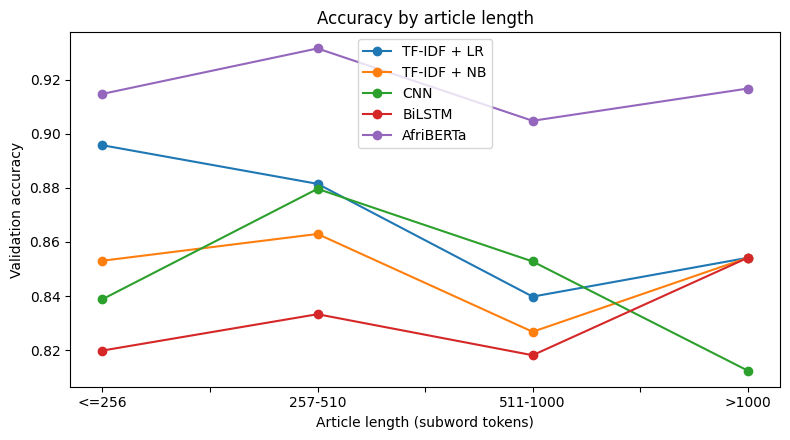

,n_articles,TF-IDF + LR,TF-IDF + NB,CNN,BiLSTM,AfriBERTa
<=256,211,0.896,0.853,0.839,0.820,0.915
257-510,540,0.881,0.863,0.880,0.833,0.931
511-1000,231,0.840,0.827,0.853,0.818,0.905
>1000,48,0.854,0.854,0.812,0.854,0.917


In [27]:
val_len = pd.Series([len(s) for s in subword_encode(val_df["content"], tokenizer, 100000)])
buckets = pd.cut(val_len, [0, 256, 510, 1000, np.inf], labels=["<=256", "257-510", "511-1000", ">1000"])
by_length = correct.groupby(buckets, observed=True).mean()
by_length.insert(0, "n_articles", buckets.value_counts().reindex(by_length.index).to_numpy())

ax = by_length.drop(columns="n_articles").plot(marker="o", figsize=(8, 4.5))
ax.set_xlabel("Article length (subword tokens)")
ax.set_ylabel("Validation accuracy")
ax.set_title("Accuracy by article length")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "accuracy_by_length.png", dpi=150)
plt.show()
by_length.round(3)

**Discussion of the comparison.**
- **Ranking.** Macro-F1: AfriBERTa 0.782 > TF-IDF + LR 0.633 > TF-IDF + NB 0.621 > BiLSTM 0.578 > CNN 0.521. Three-class macro-F1: AfriBERTa 0.925 > LR 0.879 > CNN 0.868 > NB 0.858 > BiLSTM 0.834.
- **Only the pretrained model beats the keyword baseline.** AfriBERTa is significantly better than TF-IDF + LR (it alone gets 72 articles right, against 23 for LR; p < 0.0001), and its confidence interval (0.641-0.889) lies mostly above LR's (0.561-0.684). It gains on the large classes too (`Kitaifa` F1 0.847 → 0.899, `Biashara` 0.843 → 0.902), mainly by cutting national/business confusions from 84 to 52.
- **The sequence models trained from scratch do not beat bag-of-words.** The CNN is not significantly different from LR (p = 0.27) and the BiLSTM is significantly worse (p = 0.0005). With about 4k labelled articles, learning word order from scratch adds nothing over topic keywords; the benefit of a sequential model comes from pretraining on unlabelled African-language text. This matches MasakhaNEWS (Adelani et al., 2023): simple baselines are strong on news topics, and African-language pretrained transformers are best.
- **Input length does not explain the differences.** TF-IDF + LR trained on only the first 510 subword tokens scores 0.632 vs 0.633 on the full article, and AfriBERTa's accuracy stays at 0.905-0.931 in every length bucket, including articles over 1,000 tokens (0.917). News articles state their topic early, so truncation at 512 tokens is not a real limitation for this task.
- **Calibration.** AfriBERTa also has the best log loss (0.392). The CNN is second (0.406) despite its low macro-F1, because it is well calibrated on the large classes and never commits to the small ones.
- **Trade-offs.** AfriBERTa's gain of 0.15 macro-F1 (0.046 on the three large classes) costs a GPU, about 5.5 minutes per training run and 111M parameters, and its decisions cannot be read off like TF-IDF weights. Where only the three large classes matter and interpretability is important, TF-IDF + LR (22 seconds on a CPU, including the grid search) remains a reasonable choice. Between the two baselines, LR is significantly better than NB (p = 0.017).

## 6. Error analysis

**Author:** Mukunzi Ndahiro James

### 6.1 How many models get each article right?

In [28]:
n_correct = correct.sum(axis=1)
display(n_correct.value_counts().sort_index().rename("articles").to_frame().T)

detail = val_df[["id", "category", "content"]].copy()
for m in FINAL:
    detail[NAMES[m]] = preds[m]["predicted"].to_numpy()
detail["n_correct"] = n_correct.to_numpy()
detail["words"] = detail["content"].str.split().apply(len)
detail["snippet"] = detail["content"].str.slice(0, 250)

,0,1,2,3,4,5
articles,33,30,41,63,148,715


### 6.2 Articles that every model gets wrong
If five very different models agree on the same "wrong" label, the gold label itself may be wrong or the article may genuinely belong to two categories. Read these articles and note, for each one, whether the label looks wrong, ambiguous, or correct.

In [29]:
pd.set_option("display.max_colwidth", 250)
all_wrong = detail[detail["n_correct"] == 0]
all_wrong.drop(columns="content").to_csv(RESULTS_DIR / "errors_all_models.csv", index=False)
print(f"{len(all_wrong)} articles misclassified by all five models")
display(pd.crosstab(all_wrong["category"], all_wrong["AfriBERTa"]))
all_wrong[["category"] + [NAMES[m] for m in FINAL] + ["words", "snippet"]].head(15)

33 articles misclassified by all five models


AfriBERTa,Biashara,Kitaifa,michezo
category,,,
Biashara,0,6,0
Burudani,1,1,0
Kimataifa,0,2,0
Kitaifa,10,0,10
michezo,0,3,0


,category,TF-IDF + LR,TF-IDF + NB,CNN,BiLSTM,AfriBERTa,words,snippet
44,Kitaifa,michezo,michezo,michezo,michezo,michezo,235,"WATAZAMAJI wanatakiwa kutoa kiasi cha Sh 5,000 ili kuiona Simba ikicheza dhidi ya Mbabane Swallows ya eSwatini katika mchezo wa awali wa kuwania kutwaa taji la Ligi ya Mabingwa wa Afrika kwenye Uwanja wa Taifa jijini Dar es Salaam leo.Mchezo huo ..."
51,Biashara,Kitaifa,Kitaifa,Kitaifa,Kitaifa,Kitaifa,477,"TANZANIA imeendelea kuwa juu katika sekta ya utalii Afrika Mashariki (EAC) kwa kuingiza kipato kikubwa, baada ya kuingiza dola za Marekani bilioni 2.4 mwaka jana.Mapato hayo ya Tanzania ni mbele ya Kenya, iliyoingiza dola za Marekani bilioni 1.55..."
118,Burudani,Kitaifa,Kitaifa,Biashara,Kimataifa,Kitaifa,62,.Baadhi ya mitambo ya kufanyia upasuaji wa ubongo bila kuvunja fuvu la kichwa cha binadamu ikiwa imewasili katika bandari ya Dar es salaam ikitokea nchini Ujerumani ilikonunuliwa na Serikali.Mitambo hiyo itakayofungwa katika Taasisi ya Tiba ya Mi...
125,Kitaifa,Biashara,Biashara,Biashara,Biashara,Biashara,139,"Benki Kuu ya Tanzania (BoT) imetangaza kuhamishia mali, madeni pamoja na wafanyakazi wa Benki M kwenda Benki ya Azania.Haya yamesemwa na Naibu Gavana wa BoT, Dk Benard Kibese, mapema leo, Jumanne, alipofanya mkutano na waandishi wa habari jijini ..."
128,Kitaifa,michezo,michezo,michezo,michezo,michezo,247,"LICHA ya kuwafunga waajiri wake wazamani Yanga, Mshambuliaji wa Azam FC , Obrey Chirwa (pichani) ameonesha kutoridhika na hali hiyo na kudai kuwa anaitaka Yanga yenyewe iliyotimia akimaanisha ile ya wakubwa.Chirwa alifunga bao la tatu katika mche..."
171,Biashara,Kitaifa,Kitaifa,Kitaifa,Kitaifa,Kitaifa,413,"SERIKALI kwa sasa iko katika hatua ya kuchambua na kupitia upya muundo wa kifedha na kiuchumi, utakaotumika kwenye mikataba ya uchimbaji na utafutaji wa gesi ili kuweza kuinufaisha nchi.Aidha, serikali imebainisha kuwa imejiandaa na haina wasiwas..."
232,Biashara,Kitaifa,Kitaifa,michezo,Kitaifa,Kitaifa,218,"UBANDIKAJI wa majina ya wakulima wote wa korosho kwenye mbao za matangazo katika vyama vyao vya msingi, waliolipwa fedha za mauzo ya zao hilo mkoani Mtwara, utaanza kesho ili kuondoa kauli ya kila mkulima kudai kuwa hajalipwa, jambo linaloichafua..."
244,Kitaifa,michezo,michezo,michezo,michezo,michezo,163,MSANII wa muziki nchini Richard Mavoko amekanusha taarifa kuwa aliwahi kwenda kupiga magoti ili kupata nafasi ya kurejea katika kundi WCB lililo chini ya msanii Nasib Abdul ‘Diamond Platnumz’. Mavoko aliachana na kundi hilo Julai mwaka jana kutok...
260,Burudani,Biashara,Kitaifa,Biashara,Kimataifa,Biashara,127,".Aliyekuwa Waziri wa Mambo ya Nje katika Serikali ya awamu ya Nne na kada wa Chama cha Mapinduzi (CCM) Bernard Membe amesema kuwa, kuhojiwa na Kamati ya Maadili ya chama chake ni faida kwake pamoja na ChamaAkizungumza nje ya Makao Makuu ya CCM ji..."
309,Biashara,Kitaifa,Kitaifa,Kitaifa,Kitaifa,Kitaifa,296,"CHAMA cha Wataalamu Wasaidizi wa Tiba na Afya ya Mifugo Tanzania (TAVEPA), kimebainisha kuwa Tanzania ndio nchi inayouza nyama kwa wingi katika nchi za Jumuiya ya Afrika Mashariki (EAC) kwa sasa.Kimeshauri kuwa kutokana na wingi wa soko hilo, ni ..."


### 6.3 What does reading the sequence fix?
Articles where the keyword baseline is wrong but AfriBERTa is right, and the reverse.

In [30]:
lr_ok, afri_ok = correct["TF-IDF + LR"], correct["AfriBERTa"]
print("TF-IDF + LR wrong, AfriBERTa right:", int((~lr_ok & afri_ok).sum()))
print("TF-IDF + LR right, AfriBERTa wrong:", int((lr_ok & ~afri_ok).sum()))
detail[(~lr_ok & afri_ok).to_numpy()][["category", "TF-IDF + LR", "AfriBERTa", "words", "snippet"]].head(8)

TF-IDF + LR wrong, AfriBERTa right: 72
TF-IDF + LR right, AfriBERTa wrong: 23


,category,TF-IDF + LR,AfriBERTa,words,snippet
11,Burudani,michezo,Burudani,68,".Naibu Waziri wa Habari, Utamaduni, Sanaa na Michezo Mhe. Juliana Shonza amewataka wabunifu wa Tanzania kuhalalisha kazi zao za mitindo ili kupata furusa mbalimbali zinazopita kwenye wizara kutokana na kujulikana na kutambulika na serekali kihala..."
17,Kitaifa,Biashara,Kitaifa,314,"KAMPUNI ya Ndege Tanzania (ATCL) inazindua safari ya kwanza kwenda Johanesburg, Afrika Kusini kesho. Akizungumzia uzinduzi huo, Mkurugenzi Mtendaji wa ATCL, Ladislaus Matindi alisema hatua hiyo ni mafanikio ya mpango mkakati wao ulioanza mwaka 20..."
27,Kitaifa,Kimataifa,Kitaifa,213,"BAADA ya kuwa katika hali ya mvutano na Rais Uhuru Kenyatta kwa muda mrefu, Gavana wa Mombasa, Hassan Joho anaonekana kuwa karibu na kiongozi huyo wa nchi tangu mshikamano wa nchi ulipoasisiwa na Uhuru na Raila Odinga.Katika ziara ya hivi karibun..."
33,Kitaifa,Biashara,Kitaifa,528,"NYOTA ya uwekezaji katika nchi za Jumuiya ya Afrika Mashariki (EAC), imeendelea kung’aa na itazidi kung’aa mwaka 2019.Ripoti ya Benki ya Biashara ya Rand (RMB) ya Afrika Kusini, imeonesha kuwa Afrika Mashariki itakuwa kitovu cha uwekezaji barani ..."
36,michezo,Kitaifa,michezo,279,"CHAMA cha Riadha nchini (RT), kimetoa baraka kwa wandaaji wa mbio za kujifurahisha Mbezi Fun Run zilizopangwa kufanyika Desemba Mos, jijini Dar es Salaam.Katibu Mkuu wa RT, Willihelmi Gudagudai amesema leo Alhamisi kuwa RT imetoa kibali kwa wanda..."
41,Kitaifa,Biashara,Kitaifa,391,"NDEGE nyingine mbili kubwa zilizonunuliwa na serikali ili kuendelea kuboresha Kampuni ya Ndege Tanzania (ATCL) zitawasili nchini Desemba, mwaka huu.Hayo yalibainishwa na Waziri wa Ujenzi, Uchukuzi na Mawasiliano, Isack Kamwelwe wakati akifungua m..."
52,Kitaifa,Biashara,Kitaifa,304,MAOFISA wa Shirika la Viwango Tanzania (TBS) wamefanikiwa kumkamata muagizaji wa jumla wa nguo za ndani za mitumba zilizopigwa marufuku kutumika nchini kwa mujibu wa Sheria ya Viwango namba 2 ya mwaka 2009. Kukamatwa kwake ni mafanikio makubwa kw...
94,Kitaifa,Biashara,Kitaifa,498,"MARAIS Dk John Magufuli na Profesa Arthur Peter Mutharika wa Malawi wamekubaliana kwa pamoja kukuza uchumi wa nchi zao.Akiwa nchini humo, Rais Magufuli jana alifungua msimu wa soko la tumbaku na kusema nchi za Afrika zina haja ya kufanya mapinduz..."


In [31]:
detail[(lr_ok & ~afri_ok).to_numpy()][["category", "TF-IDF + LR", "AfriBERTa", "words", "snippet"]].head(8)

,category,TF-IDF + LR,AfriBERTa,words,snippet
60,Biashara,Biashara,Kitaifa,927,UGANDA imetimiza ndoto zake za kutengeneza magari ambapo inakuwa nchi ya nne kati ya sita za Afrika Mashariki.Nchi hiyo iko mbioni kutengeneza mabasi ya kisasa ya abiria kwa ajili ya biashara ndani na nje ya Afrika Mashariki wakati wa Krismasi kw...
166,Kitaifa,Kitaifa,Biashara,453,"ZIARA ya Naibu Waziri wa Madini, Stanslaus Nyongo aliyoifanya katika mgodi wa dhahabu wa Nyakavangala wilayani Iringa imewaponza wamiliki wanane wa mgodi huo waliojikuta mikononi mwa Polisi baada ya taarifa zao kuonesha kuna udanganyifu wa kiwang..."
195,Kitaifa,Kitaifa,Kimataifa,132,"GAVANA wa jimbo la Juba, Augustino Jadalla Wani ametangaza kufungwa kwa klabu zote za usiku katika eneo lake na kuweka muda maalumu wa baa kufanya kazi.Alisema baa zote zimeruhusiwa kufunguliwa kuanzia saa 11 jioni mpaka saa tatu hadi nne usiku l..."
254,Kitaifa,Kitaifa,Biashara,127,"Naibu Waziri wa Ujenzi, Uchukuzi na Mawasiliano Mhandisi Atashasta Nditiye amesema wenza wa wabunge wana haki ya kuhudumiwa kwa viwango vya VIP kwenye viwanja vya ndege nchini.Amelazimika kutoa maelezo hayo wakati akijibu swali la Mbunge wa Nyang..."
263,Kitaifa,Kitaifa,michezo,130,Tamasha la muziki la Wasafi Festival linatarajiwa kufanyika kwenye mikoa minane kuanzia Julai mwaka huu. Wasafi Festival litafanyika sanjari na utoaji wa elimu ya matumizi sahihi ya kondom ili kujikinga kupata virusi vinavyosababisha upungufu wa ...
301,Kitaifa,Kitaifa,Biashara,505,"Serikali za Uganda na Tanzania zimekubaliana kuwa ujenzi wa mradi wa Bomba la mafuta Ghafi kutoka Hoima Uganda hadi Tanga Tanzania, uanze mwezi Juni mwaka huu na ukamilike baada ya miezi 36, yaani mwezi Juni mwaka 2022.Pia, zimekubaliana kuwa maj..."
310,Biashara,Biashara,Kitaifa,191,"SERIKALI mkoani Lindi imesema wakulima wote wa korosho ambao hawajalipwa pesa zao zilizosalia Sh bilioni 222.7, watalipwa fedha hizo ifikapo mwishoni mwa mwezi huu.Waziri wa Kilimo, Japhet Hasunga amesema hayo mjini Lindi alipozungumza na Kamati ..."
323,Kitaifa,Kitaifa,Biashara,315,"MKUU wa Wilaya ya Chemba, Saimon Odunga amesema kesho watazindua utaratibu wa ugawaji wa vitambulisho vya wajasiriamali baada ya kupitisha vigezo ambavyo wanaona wanaweza kupata wajasiriamali.Akizungumza na gazeti hili kwa njia ya simu, Odunga al..."


### 6.4 The two small classes
Every validation article of `Kimataifa` and `Burudani`, with each model's prediction.

In [32]:
detail[detail["category"].isin(["Kimataifa", "Burudani"])][["category"] + [NAMES[m] for m in FINAL] + ["words", "snippet"]]

,category,TF-IDF + LR,TF-IDF + NB,CNN,BiLSTM,AfriBERTa,words,snippet
11,Burudani,michezo,Kitaifa,michezo,Burudani,Burudani,68,".Naibu Waziri wa Habari, Utamaduni, Sanaa na Michezo Mhe. Juliana Shonza amewataka wabunifu wa Tanzania kuhalalisha kazi zao za mitindo ili kupata furusa mbalimbali zinazopita kwenye wizara kutokana na kujulikana na kutambulika na serekali kihala..."
118,Burudani,Kitaifa,Kitaifa,Biashara,Kimataifa,Kitaifa,62,.Baadhi ya mitambo ya kufanyia upasuaji wa ubongo bila kuvunja fuvu la kichwa cha binadamu ikiwa imewasili katika bandari ya Dar es salaam ikitokea nchini Ujerumani ilikonunuliwa na Serikali.Mitambo hiyo itakayofungwa katika Taasisi ya Tiba ya Mi...
193,Kimataifa,Burudani,Burudani,michezo,michezo,Kimataifa,110,"Jarida maarufu duniani la Forbes limemtangaza mwanamziki wa Hip Hop kutoka Marekani Shawn Carter ‘Jay-Z’ kuwa ni rapa wa kwanza duniani kuingia katika orodha ya mabilionea. Inaelezwa kuwa, mafanikio ya mwanamuziki huyo yamekuja baada ya kujenga u..."
208,Kimataifa,Kimataifa,Kimataifa,Kitaifa,michezo,Kimataifa,133,"MAHARUSI wawili wameibua hisia za watu mbalimbali nchini Marekani hivi karibuni baada ya kupata ajali ya helikopta na kufariki takribani saa mbili tu baada ya kufunga ndoa.Inaelezwa kuwa wawili hao, Will na Bailee Byler walifunga ndoa yao jioni y..."
260,Burudani,Biashara,Kitaifa,Biashara,Kimataifa,Biashara,127,".Aliyekuwa Waziri wa Mambo ya Nje katika Serikali ya awamu ya Nne na kada wa Chama cha Mapinduzi (CCM) Bernard Membe amesema kuwa, kuhojiwa na Kamati ya Maadili ya chama chake ni faida kwake pamoja na ChamaAkizungumza nje ya Makao Makuu ya CCM ji..."
299,Kimataifa,Kitaifa,Kitaifa,Kitaifa,Kimataifa,Kimataifa,93,".Mahakama nchini Afrika Kusini imetoa hati ya kukamatwa kwa Rais Mstaafu wa nchi hiyo, Jacob Zuma kutokana na kutofika mahakamani katika kesi ya rushwa inayomkabili.Rais Zuma alitarajiwa kufika mbele ya Mahakama Kuu ya Pietermaritizburg, lakini h..."
300,Kimataifa,Kitaifa,Kitaifa,Kitaifa,Kitaifa,Kimataifa,96,Wanasayansi wa Ufaransa wameeleza uwezekano wa vinywaji vya sukari ikiwa ni pamoja na juisi za matunda kuwa na hatari ya kusababisha saratani. Wanasayansi hao kutoka Chuo Kikuu cha Srbonne Paris Cite wameeleza kuwa kutokana na viwango vya sukari ...
354,Kimataifa,Kitaifa,Kitaifa,Kitaifa,michezo,Kimataifa,232,"ALIYEKUWA muuguzi wa hospitali mbili tofauti nchini Ujerumani, Niels Hogel (42) amehukumiwa kifungo cha maisha jela baada ya kupatikana na hatia ya kuua wagonjwa 85 kwa makusudi.Jaji wa mahakama iliyomtia hatiani muuguzi huyo, Sebastian Buehrmann..."
381,Kimataifa,Kitaifa,Kitaifa,Kitaifa,michezo,Kitaifa,150,"Baadhi ya nchi Barani Afrika zikiwemo Rwanda na Uganda zimesherehekea Sikukuu ya Eid al-Filtr leo, Jumanne. Mbali na nchi hizo, Waislam katika nchi za Somalia, Ethiopia, Sierra Leone na Jamhuri ya Kidemokrasi ya Congo (DRC) nao wameshiriki ibada ..."
383,Kimataifa,Kimataifa,Kimataifa,Kitaifa,Burudani,Kitaifa,176,".Salamu za pole zimeendelea kutolewa kwa Rais Uhuru Kenyatta wa Kenya na raia wote wa nchi hiyo, kufuatia kifo cha Rais wa Pili wa Taifa hilo Mzee Daniel arap Moi kilichotokea hii leo.Salamu za hivi karibuni zimetoka kwa Waziri Mkuu wa Ethiopia, ..."


### 6.5 Most frequent confusions and the most confident mistakes

In [33]:
pairs = pd.DataFrame({NAMES[m]: (preds[m]["category"] + " -> " + preds[m]["predicted"])[preds[m]["category"] != preds[m]["predicted"]].value_counts()
                      for m in FINAL}).fillna(0).astype(int)
pairs.loc[pairs.sum(axis=1).sort_values(ascending=False).index].head(8)

,TF-IDF + LR,TF-IDF + NB,CNN,BiLSTM,AfriBERTa
Kitaifa -> Biashara,48,50,64,37,34
Biashara -> Kitaifa,36,45,28,56,18
michezo -> Kitaifa,17,30,15,22,4
Kitaifa -> michezo,13,12,15,30,13
Kimataifa -> Kitaifa,5,6,9,2,4
michezo -> Biashara,3,4,5,5,2
Kitaifa -> Kimataifa,2,0,0,4,4
Biashara -> michezo,0,0,1,8,0


In [34]:
best_model = metrics["macro_f1"].idxmax()
p = preds[best_model]
conf = p[[f"p_{l}" for l in LABELS]].max(axis=1)
wrong = (p["predicted"] != p["category"]).to_numpy()
print("Best model by validation macro-F1:", NAMES[best_model])
detail.assign(confidence=conf.round(3).to_numpy())[wrong].sort_values("confidence", ascending=False)[
    ["category", NAMES[best_model], "confidence", "words", "snippet"]].head(10)

Best model by validation macro-F1: AfriBERTa


,category,AfriBERTa,confidence,words,snippet
125,Kitaifa,Biashara,0.999,139,"Benki Kuu ya Tanzania (BoT) imetangaza kuhamishia mali, madeni pamoja na wafanyakazi wa Benki M kwenda Benki ya Azania.Haya yamesemwa na Naibu Gavana wa BoT, Dk Benard Kibese, mapema leo, Jumanne, alipofanya mkutano na waandishi wa habari jijini ..."
135,Kitaifa,Biashara,0.999,519,"WAZIRI Mkuu, Kassim Majaliwa ameahidi kupokea kundi la watalii wasiopungua 300 wanaotarajiwa kuwasili nchini Machi, mwaka huu.Watalii hao ni kundi la kwanza miongoni mwa watalii 10,000 wanaotarajiwa kuwasili nchini mwaka huu chini ya mpango unaos..."
696,Biashara,Kitaifa,0.999,540,"RAIS John Magufuli amewataka Watanzania likiwemo Jeshi la Ulinzi la Wananchi wa Tanzania (JWTZ) kufanya biashara na Wakenya kwa kuwauzia unga wa mahindi.Alitoa kauli hiyo Ikulu, Dar es Salaam jana wakati akishuhudia makabidhiano ya fedha taslimu ..."
792,Kitaifa,Biashara,0.999,240,"Mkutano Mkuu wa kampuni ya umma ya Jenga Afya, Teketeza Umasikini (Jatu TLC) unatarajiwa kufanyika Jumamosi June Mosi, katika Ukumbi wa Mgulani jijini Dar es Salaam.Wakati wa mkutano huo wanachama wa kampuni hiyo watachagua viongozi wapya wa bodi..."
761,Biashara,Kitaifa,0.999,122,SHILINGI bilioni 2.5 zinatarajiwa kutumika kwenye Mradi wa Kukabiliana na Maafa wilayani Kyela mkoani Mbeya wa Disaster Preparedness (DP3) utakaoendeshwa kwa miaka miwili na Chama cha Msalaba Mwekundu nchini.Kwa mujibu wa Mkurugenzi wa Idara ya M...
994,Kitaifa,Biashara,0.999,321,"SERA ya Uchumi wa Kati kupitia ujenzi wa viwanda, umepata msukumo baada ya Kampuni ya IPP kuingia ubia wa kuanzisha kiwanda cha kuunganisha magari kutoka Jamhuri ya Korea maarufu kama Korea Kusini, kinachotarajiwa kuzalisha magari 1,000 kwa mwaka..."
909,Kitaifa,Biashara,0.999,240,"MAKAMU wa Rais, Samia Suluhu Hassan ameshiriki katika Mkutano wa 12 wa Dharura wa Wakuu wa Nchi na Serikali wa Umoja wa Afrika kuhusu Mkataba wa Uanzishwaji wa Eneo Huru la Biashara la Afrika (AfCFTA), unaofanyika jijini Niamey, Niger.Akiwa katik..."
898,Kitaifa,Biashara,0.999,331,Imeelezwa kuwa ujenzi wa jengo la abiria katika Kiwanja cha Ndege cha Tabora ambao utaweza kuchukua abiria 500 kwa wakati mmoja utaanza hivi karibuni ili kuufanya uwanja huo kuwa na hadhi ya kupokea ndege kubwa nyingi.Hayo yamesemwa mkoani humo n...
845,Kitaifa,Biashara,0.999,248,BENKI ya Maendeleo ya Afrika (AfDB) inatarajia kuipandisha daraja Tanzania kutoka katika hadhi ya kunufaika na Mfuko wa Maendeleo wa Benki (ADF) hadi kuwa na hadhi itakayoiwezesha Tanzania kuweza kupata rasilimali fedha zaidi kupitia dirisha la A...
657,Kitaifa,Biashara,0.999,350,WAJASIRIAMALI 349 kutoka vijiji 59 vya mikoa ya Tanga na Pwani wamenufaika na mradi wa matumizi mazuri ya nishati ya umeme kwa kufungua biashara ndogo na kufanya shughuli za maendeleo.Hayo yalielezwa na Meneja Mradi Matumizi ya Umeme katika kujil...


**Error analysis.**
- **Agreement:** 715 of the 1,030 validation articles (69%) are classified correctly by all five models and 33 by none.
- **Articles every model gets wrong often look mislabelled or ambiguous.** All five models predict `michezo` for several articles labelled `Kitaifa` that are clearly about football: Simba's CAF Champions League match (row 44), the Afcon 2019 opening (row 527), Nigeria's Super Eagles (row 431). These look like labelling errors, or a convention that no text model can infer. Other shared errors sit on the national/business boundary: a Bank of Tanzania transfer of Bank M's assets labelled `Kitaifa` (row 125), and tourism revenue labelled `Biashara` (row 51). Either label is defensible for these. Among the three validation `Burudani` articles, one is about brain-surgery equipment arriving at Dar es Salaam port (row 118) and one about a former foreign minister (row 260); neither reads as entertainment news, which caps the achievable `Burudani` F1.
- **What pretraining fixes.** AfriBERTa corrects 72 of LR's errors and introduces 23 new ones. Most of the corrected articles are `Kitaifa` stories with business vocabulary but a government actor, for example ATCL's new flights, a TBS seizure and an EAC investment report, which LR assigned to `Biashara` from keywords alone. A telling case is row 11: a deputy minister urging fashion designers to register their work is `Burudani`, but LR predicts `michezo`, probably from *Michezo* in the ministry's name (*Wizara ya Habari, Utamaduni, Sanaa na Michezo*); AfriBERTa reads the context and gets it right.
- **What AfriBERTa breaks** is mostly again the national/business boundary, and sometimes AfriBERTa looks more correct than the gold label: an article about the governor of Juba closing nightclubs is labelled `Kitaifa`, but AfriBERTa predicts `Kimataifa` (row 195).
- **Small classes.** AfriBERTa finds 7 of 11 `Kimataifa` articles. Its misses are predicted as `Kitaifa`, including Theresa May's resignation (row 515) and Jack Ma's comments (row 856), which are genuine failures. Articles mixing celebrity and international news sit between the two small classes: Jay-Z's Forbes ranking (row 193) is labelled `Kimataifa`, and both keyword baselines predict `Burudani`, while AfriBERTa gets it right.
- **The main confusion is the same for every model.** `Kitaifa` ↔ `Biashara` accounts for 84 of LR's 130 errors and 52 of AfriBERTa's 81. AfriBERTa's ten most confident mistakes (probability 0.999) are all of this kind: the Bank of Tanzania, tourism plans announced by the prime minister, and the AfCFTA summit. The model is certain, and the gold label depends on an editorial choice. Together with the 7 near-duplicate pairs labelled both ways (notebook 01), this points to label noise, not model capacity, as the main remaining source of error on the large classes.

## 7. Limitations

**Data.**
- All articles come from Tanzanian news websites. Kenyan, Ugandan and Congolese Swahili differ in vocabulary and spelling, so these results do not tell us how the models would perform on news from those countries.
- The named people in the data (for example Magufuli and Trump) place the articles in a limited period. Models that rely on names will degrade as the news moves on.
- With 17 `Burudani` and 54 `Kimataifa` articles, every result for these classes rests on a handful of examples: the validation set has only 3 and 11 of them.
- Some articles appear to be mislabelled (Section 6.2). Label noise limits the best achievable score and makes some "errors" correct predictions.

**Method.**
- A single train/validation split and a single seed were used. Neural results can vary by several points between seeds, so small differences between models should not be over-interpreted.
- The neural models read at most 512 tokens, although many articles are longer.
- Hyperparameters for the neural models were set from common defaults rather than searched systematically.
- The development split contains only 1 `Burudani` and 4 `Kimataifa` articles, so choosing epochs and experiments on development macro-F1 is noisy; for the BiLSTM the chosen experiment was not the best on validation.
- AfriBERTa was trained for at most 5 epochs, and its development macro-F1 was still rising at the end.

## 8. Summary

| Approach | Macro-F1 (95% CI) | Macro-F1, 3 large classes | Accuracy | Log loss | `Kimataifa` F1 | `Burudani` F1 |
|---|---|---|---|---|---|---|
| TF-IDF + LR | 0.633 (0.561-0.684) | 0.879 | 0.874 | 0.457 | 0.526 | 0.000 |
| TF-IDF + NB | 0.621 (0.538-0.680) | 0.858 | 0.852 | 0.526 | 0.533 | 0.000 |
| 1D CNN | 0.521 (0.508-0.533) | 0.868 | 0.862 | 0.406 | 0.000 | 0.000 |
| BiLSTM | 0.578 (0.494-0.666) | 0.834 | 0.828 | 0.549 | 0.100 | 0.286 |
| **AfriBERTa** | **0.782 (0.641-0.889)** | **0.925** | **0.921** | **0.392** | **0.636** | **0.500** |

Sequential modelling helps on Swahili news classification only when it comes with pretraining. Fine-tuned AfriBERTa is the best approach on every metric, and it is the only model that recognises the two tiny classes reasonably well. The CNN and BiLSTM, which learn from about 4k labelled articles alone, do not beat a TF-IDF keyword baseline; the BiLSTM in particular overfits heavily. Truncation to 512 tokens costs almost nothing, because news articles state their topic early. The remaining errors are dominated by the national/business boundary, where near-duplicate articles carry conflicting labels, and by the handful of `Burudani` and `Kimataifa` examples, which make every macro-F1 estimate uncertain.